# 03 — A commission rate benchmark, and what it says the pricing costs

Notebook 02 ended with a narrow, testable question.

Softwood's rate on a negotiated deal is set by whoever is handling it. Within a
single customer, a single supplier and a single year, we saw rates ranging from
0.8% to 11.7%. Nobody in the company has a reference point for what a deal
*should* carry.

So: **can we build that reference point from the company's own history, and does
it hold up on deals the method has never seen?**

This is the same idea a property valuer uses. You do not price a plot by
intuition — you look at what comparable plots in the same area recently sold for,
and you flag anything well outside that range.

Three things have to be true for this to be worth building, and we test each one
rather than assume it:

1. There has to be real variation to explain, in a defined part of the business
2. Some grouping of past deals has to predict the rate better than doing nothing,
   **on deals it has not seen**
3. The result has to translate into a number a business person can act on


In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import viz
from sklearn.metrics import mean_absolute_error

viz.use_style()
pd.set_option("display.width", 200)

deals = pd.read_csv("../data/processed/deals_clean.csv", parse_dates=["contract_date"])
print(f"{len(deals):,} clean deals")

4,590 clean deals


## Step 1 — Decide what is in scope, and be strict about it

Notebook 01 found that the product line hidden inside the customer name splits
this business in two. Before building anything, we check which half has a
pricing question at all.


In [2]:
scope = deals.groupby("product_division").commission_pct.agg(
    deals="size", p25=lambda s: s.quantile(.25), median="median",
    p75=lambda s: s.quantile(.75))
scope["IQR"] = (scope.p75 - scope.p25)
scope["rate is"] = np.where(scope.IQR < 0.001, "fixed by contract", "negotiated per deal")
scope.round(4)

,deals,p25,median,p75,IQR,rate is
product_division,,,,,,
denim,58,0.0200,0.0200,0.0200,0.0000,fixed by contract
fab,730,0.0200,0.0200,0.0200,0.0000,fixed by contract
garment,2931,0.0200,0.0314,0.0500,0.0300,negotiated per deal
knit,871,0.0365,0.0500,0.0646,0.0281,negotiated per deal


Fabric and denim deals have an inter-quartile range of **exactly zero**. Every
one of them is at the contract rate. A benchmark for these would be a tool that
tells you 2% when the answer is always 2% — solving a problem that does not
exist.

So the benchmark covers the **knit and garment lines only**. That is 3,802 deals,
83% of the book, and it is where all of the variation lives. Writing the scope
into the code rather than a comment means the model physically cannot score a
fabric deal by accident.


In [3]:
from benchmark import negotiated_only, NEGOTIATED_DIVISIONS

negotiated = negotiated_only(deals)
print(f"In scope  : {NEGOTIATED_DIVISIONS} -> {len(negotiated):,} deals ({len(negotiated)/len(deals):.0%})")
print(f"Out of scope: fabric and denim -> {len(deals) - len(negotiated):,} deals")

In scope  : ('knit', 'garment') -> 3,802 deals (83%)
Out of scope: fabric and denim -> 788 deals


## Step 2 — Find the peer group, honestly

A benchmark is only as good as its idea of "comparable". We have several
candidates: group by customer, by supplier, by both, or let a machine learning
model work it out from everything at once.

The only test that means anything is a test on deals the method has not seen. We
train on 2019-2023 and score 2024-2025. This matters more than it sounds — an
earlier version of this project reported 98% accuracy from a random split with
the answer among the inputs, and that number was worthless.

We compare everything against a deliberately stupid baseline: **quote the overall
median rate to everyone**. Any method that cannot beat that has earned nothing.


In [4]:
train = negotiated[negotiated.contract_year <= 2023]
test = negotiated[negotiated.contract_year >= 2024]
actual = test.commission_pct
house_median = train.commission_pct.median()

print(f"train: {len(train):,} deals (2019-2023)")
print(f"test : {len(test):,} deals (2024-2025)")


def evaluate(prediction, name, store={}):
    prediction = np.asarray(prediction, dtype=float)
    store[name] = {
        "MAE (pp)": mean_absolute_error(actual, prediction) * 100,
        "R2": 1 - ((actual - prediction) ** 2).sum() / ((actual - actual.median()) ** 2).sum(),
    }
    return store


def group_median(keys, k=0):
    # k = 0 means the raw group median; k > 0 shrinks it toward the house median.
    stats = train.groupby(keys).commission_pct.agg(["median", "size"])
    weight = stats["size"] / (stats["size"] + k) if k else 1.0
    blended = weight * stats["median"] + (1 - weight) * house_median
    key = test[keys[0]] if len(keys) == 1 else pd.MultiIndex.from_frame(test[keys])
    return pd.Series(key.map(blended), index=test.index).astype(float).fillna(house_median)


results = evaluate(np.full(len(test), house_median), "Quote the house median to everyone")
evaluate(group_median(["customer"]), "Customer's own median")
evaluate(group_median(["supplier"]), "Supplier's own median")
evaluate(group_median(["customer", "supplier"]), "Customer + supplier median")
evaluate(group_median(["supplier"], k=30), "Supplier median, shrunk")
print(f"{len(results)} methods evaluated on the 2024-25 holdout")

train: 2,997 deals (2019-2023)
test : 805 deals (2024-2025)
5 methods evaluated on the 2024-25 holdout


In [5]:
from sklearn.ensemble import HistGradientBoostingRegressor

features = ["customer", "supplier", "product_division", "team_head"]
train_ml, test_ml = train.copy(), test.copy()
for col in features:
    levels = sorted(train_ml[col].astype(str).unique())
    train_ml[col] = pd.Categorical(train_ml[col].astype(str), categories=levels)
    unseen = ~test_ml[col].astype(str).isin(levels)
    test_ml[col] = pd.Categorical(test_ml[col].astype(str).mask(unseen), categories=levels)
for frame in (train_ml, test_ml):
    frame["log_qty"] = np.log1p(frame.contract_qty)
model_cols = features + ["log_qty", "unit_rate_usd", "contract_month"]

ml = HistGradientBoostingRegressor(categorical_features="from_dtype", random_state=0,
                                   max_iter=400, learning_rate=0.06)
ml.fit(train_ml[model_cols], train_ml.commission_pct)
evaluate(ml.predict(test_ml[model_cols]), "Gradient boosting on everything")

table = pd.DataFrame(results).T.sort_values("MAE (pp)")
table["vs baseline"] = (1 - table["MAE (pp)"] / table.loc["Quote the house median to everyone", "MAE (pp)"])
table.round(4)

,MAE (pp),R2,vs baseline
"Supplier median, shrunk",1.7558,0.1376,0.2495
Supplier's own median,1.8169,0.1156,0.2234
Customer + supplier median,1.9140,0.1063,0.1819
Customer's own median,2.0469,0.1085,0.1250
Gradient boosting on everything,2.1453,0.1566,0.0830
Quote the house median to everyone,2.3395,0.0337,0.0000


### One note on how R² is measured here

The R² above is calculated against a *median* baseline rather than the
conventional mean, because the rate distribution is skewed and the median is what
this benchmark actually competes with. That is a non-standard choice, so here are
the same models scored the conventional way, to show the ranking does not depend
on it.


In [6]:
def r2_against_mean(prediction):
    prediction = np.asarray(prediction, dtype=float)
    return 1 - ((actual - prediction) ** 2).sum() / ((actual - actual.mean()) ** 2).sum()

conventional = {
    "Quote the house median to everyone": np.full(len(test), house_median),
    "Customer's own median": group_median(["customer"]),
    "Supplier's own median": group_median(["supplier"]),
    "Customer + supplier median": group_median(["customer", "supplier"]),
    "Supplier median, shrunk": group_median(["supplier"], k=30),
    "Gradient boosting on everything": ml.predict(test_ml[model_cols]),
}
pd.DataFrame({
    "R2 (vs median baseline)": {k: v["R2"] for k, v in results.items()},
    "R2 (vs mean baseline)": {k: r2_against_mean(v) for k, v in conventional.items()},
}).round(4)

,R2 (vs median baseline),R2 (vs mean baseline)
Quote the house median to everyone,0.0337,-0.0005
Customer's own median,0.1085,0.0769
Supplier's own median,0.1156,0.0843
Customer + supplier median,0.1063,0.0746
"Supplier median, shrunk",0.1376,0.1070
Gradient boosting on everything,0.1566,0.1267


**The simplest method wins, and it is not close on the metric that matters.**

A shrunk supplier median lands at **1.76 percentage points** of average error,
**25% better** than doing nothing. Gradient boosting, given every column we have,
comes in at 2.15pp — *worse than the plain supplier median*.

There is a real subtlety here and it is worth being precise about, because it is
the kind of thing that separates a number from an understanding.

**Gradient boosting has the better R² (15.7% against 13.8%) and the worse MAE.**
Those two metrics disagree because R² is built on squared error, so it rewards
getting the large deals right, while MAE treats every deal the same. The model is
fitting the big contracts better and the ordinary ones worse.

For this tool, MAE is the correct metric. A sourcing manager checking a routine
\$40,000 order needs the number in front of them to be right; they are not
running a portfolio. So we take the simple estimator, and we say plainly that we
chose it on MAE and that the other model wins on R².

Why does the supplier beat the customer? Plausibly because the rate reflects what
the mill will concede rather than what the buyer will pay — but the data cannot
confirm that, and we are not going to claim it.

### The shrinkage part, and why it is there

Some suppliers appear 300 times, some four times. A median from four deals is
noise dressed as a number. Shrinkage blends each supplier's own median with the
house median in proportion to its history:

$$\text{benchmark}_s = w_s \cdot \text{median}_s + (1 - w_s) \cdot \text{median}_{\text{house}}, \qquad w_s = \frac{n_s}{n_s + k}$$

A supplier with 300 deals keeps 91% of its own number; one with 4 deals keeps 12%
and mostly inherits the house average. It is one line of arithmetic and it is the
difference between a benchmark and a rumour.


In [7]:
for k in [0, 10, 20, 30, 40, 60, 80, 120, 200]:
    mae = mean_absolute_error(actual, group_median(["supplier"], k=k)) * 100
    print(f"  k = {k:3d}   MAE = {mae:.3f}pp" + ("   <- chosen" if k == 30 else ""))

  k =   0   MAE = 1.817pp
  k =  10   MAE = 1.773pp
  k =  20   MAE = 1.760pp
  k =  30   MAE = 1.756pp   <- chosen
  k =  40   MAE = 1.756pp
  k =  60   MAE = 1.757pp
  k =  80   MAE = 1.759pp
  k = 120   MAE = 1.767pp
  k = 200   MAE = 1.784pp


The result barely moves between k=20 and k=80, which is what we want to see —
the method is not balanced on a knife edge. We use k=30.

## Step 3 — From a number to a band

A single expected rate is not usable advice. Told "the benchmark is 4.8%", nobody
knows whether 4.5% is fine or a problem. So the benchmark returns a **range** —
the 25th to 75th percentile of what comparable deals actually carried — and a
deal is only called out when it falls below that range.

That choice makes the tool deliberately quiet. Ordinary variation stays silent so
that the flags mean something.


In [8]:
from benchmark import RateBenchmark

bench = RateBenchmark().fit(train)
examples = ["Samad Rubber", "Rajby", "MR Industries", "Interloop", "Umer faizan"]
pd.DataFrame([{"supplier": s, **{k: v for k, v in bench.lookup(s).items() if k != "basis"}}
              for s in examples]).assign(
    low=lambda t: (t.low * 100).round(2), expected=lambda t: (t.expected * 100).round(2),
    high=lambda t: (t.high * 100).round(2)).rename(
    columns={"low": "low %", "expected": "expected %", "high": "high %",
             "support": "past deals"})

,supplier,low %,expected %,high %,past deals
0,Samad Rubber,3.79,4.97,5.00,315
1,Rajby,4.48,4.95,5.04,142
2,MR Industries,3.43,4.94,5.00,138
3,Interloop,3.67,4.94,5.00,127
4,Umer faizan,1.74,3.11,5.83,48


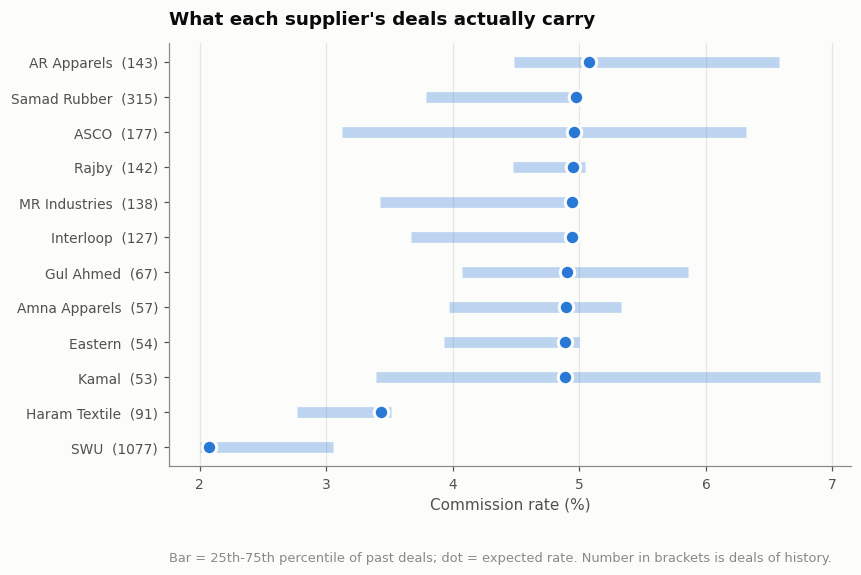

In [9]:
shown = (train.groupby("supplier").size().sort_values(ascending=False).head(12).index)
bands = pd.DataFrame([{"supplier": s, **bench.lookup(s)} for s in shown]).sort_values("expected")

fig, ax = plt.subplots(figsize=(8, 5))
positions = np.arange(len(bands))
ax.hlines(positions, bands.low * 100, bands.high * 100,
          color=viz.SERIES[0], lw=7, alpha=0.30, zorder=3)
ax.scatter(bands.expected * 100, positions, s=90, color=viz.SERIES[0],
           edgecolors=viz.SURFACE, linewidths=2, zorder=5)
ax.set_yticks(positions, [f"{s}  ({n})" for s, n in zip(bands.supplier, bands.support)])
ax.set_xlabel("Commission rate (%)")
ax.set_title("What each supplier's deals actually carry")
viz.grid(ax, axis="x")
viz.caption(ax, "Bar = 25th-75th percentile of past deals; dot = expected rate. Number in brackets is deals of history.")
plt.show()

These are not the same business. Most mills sit around 5%, but SWU deals sit at
2.1% and Haram Textile at 3.4% — different normals, on 1,077 and 91 deals of
history respectively. A single company-wide target would be wrong for all of
them. Note too how the band width tracks confidence: Rajby's 142 consistent deals
give a tight 4.5-5.0% range, while Kamal's 53 scattered ones give 3.4-6.9%.

## Step 4 — Score the whole history

Now we run the benchmark back over the company's own past to ask: how many deals
were signed below their peer range, and what did that cost?

One rule makes this honest. A deal is scored using a benchmark built **only from
earlier years**. Judging 2021 with a benchmark that has seen 2021 would be
marking your own homework, and the resulting number would be fiction. So the
benchmark is rebuilt at the start of every year from history alone — which is
also exactly how the company would run it.


In [10]:
from benchmark import walk_forward

scored = walk_forward(deals)
scored.to_csv("../data/processed/deals_scored.csv", index=False)

print(f"Scored {len(scored):,} of {len(negotiated):,} negotiated deals "
      f"({len(scored)/len(negotiated):.0%}).")
print("2019-2020 are used as history only, so they are never scored.\n")
print(scored.position.value_counts().to_frame("deals").assign(
    share=lambda t: (t.deals / t.deals.sum()).map("{:.1%}".format)).to_string())

Scored 3,421 of 3,802 negotiated deals (90%).
2019-2020 are used as history only, so they are never scored.

             deals  share
position                 
within band   2062  60.3%
above band    1063  31.1%
below band     296   8.7%


Roughly 60% of deals land inside their band, 31% above it and **8.7% below**.

That split is worth a comment rather than a shrug. Because shrinkage pulls every
band toward a house median that sits below most suppliers' own medians, the bands
are conservative on the low side — so the tool under-flags rather than over-flags.
Whatever number comes out next is therefore an **understatement**, which is the
safe direction for a claim that a business is going to act on.

## Step 5 — Put a number on it


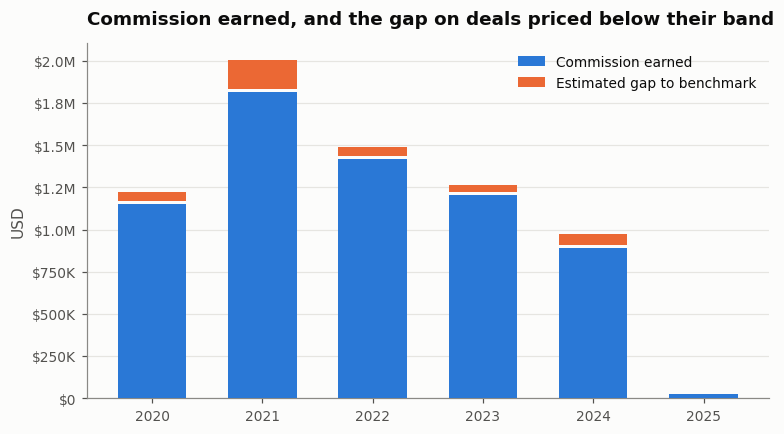

Estimated total gap, 2020-2025:  $393,252
Commission earned, same deals:   $6,508,805
Gap as a share of commission:    6.0%



,deals,below_band,commission,gap,gap as % of commission
contract_year,,,,,
2020,606,41,1153239.440,53320.352,0.046
2021,730,92,1813599.200,176858.557,0.098
2022,569,39,1417547.349,56923.386,0.040
2023,711,28,1204657.750,44005.025,0.037
2024,767,96,892178.850,62145.135,0.070
2025,38,0,27581.990,0.000,0.000


In [11]:
by_year = scored.groupby("contract_year").agg(
    deals=("leakage_usd", "size"),
    below_band=("position", lambda s: (s == "below band").sum()),
    commission=("commission_usd", "sum"),
    gap=("leakage_usd", "sum"))
by_year["gap as % of commission"] = by_year.gap / by_year.commission

total_gap = scored.leakage_usd.sum()
total_commission = scored.commission_usd.sum()

fig, ax = plt.subplots(figsize=(8, 4.2))
years = by_year.index
ax.bar(years, by_year.commission, color=viz.SERIES[0], width=0.62,
       label="Commission earned", zorder=3)
ax.bar(years, by_year.gap, bottom=by_year.commission + 18_000, color=viz.SERIES[1],
       width=0.62, label="Estimated gap to benchmark", zorder=3)
ax.set_title("Commission earned, and the gap on deals priced below their band")
ax.set_ylabel("USD")
ax.yaxis.set_major_formatter(plt.FuncFormatter(viz.money))
ax.legend(loc="upper right")
viz.grid(ax)
plt.show()

print(f"Estimated total gap, 2020-2025:  ${total_gap:,.0f}")
print(f"Commission earned, same deals:   ${total_commission:,.0f}")
print(f"Gap as a share of commission:    {total_gap/total_commission:.1%}\n")
by_year.round(3)

**About \$393,000 across roughly five years — 6.0% of commission earned on the
deals covered.**

That number needs a fence around it, and the fence is as important as the number.

**What it is:** the money that would have been earned if the 8.7% of deals priced
below their supplier's normal range had instead been priced at that supplier's
median rate. It is a measure of pricing inconsistency, quantified in dollars.

**What it is not:** it is not recoverable cash, and it is not a claim that anyone
made a mistake. Some of those deals were almost certainly priced low on purpose —
to win a first order from a new buyer, to keep a mill busy in a slow month, or as
part of a package negotiated across several contracts at once. The dataset has no
column for intent, so we cannot separate a deliberate discount from an accidental
one, and we are not going to pretend otherwise.

The honest framing is: **this is the size of the question, not the size of the
prize.** \$393,000 of pricing sits outside the company's own normal range, and
right now nobody knows which part of it was intentional. The value of the tool is
that it turns that from an unknown into a list someone can go through.

## Step 6 — Make it actionable

An aggregate number does not change any behaviour. A list of specific deals does.


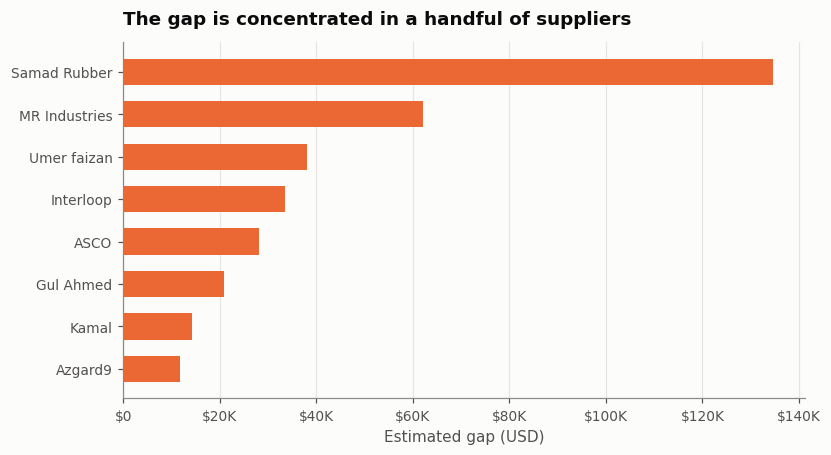

Top 3 suppliers account for 60% of the total gap.



,deals,below_band,gap,share of gap
supplier,,,,
Samad Rubber,310,86,134563.600,0.342
MR Industries,135,37,62089.367,0.500
Umer faizan,56,13,37991.117,0.597
Interloop,124,13,33585.122,0.682
ASCO,242,33,28217.747,0.754
Gul Ahmed,77,11,20955.592,0.807
Kamal,95,12,14280.065,0.843
Azgard9,45,3,11668.927,0.873


In [12]:
by_supplier = scored.groupby("supplier").agg(
    deals=("leakage_usd", "size"),
    below_band=("position", lambda s: (s == "below band").sum()),
    gap=("leakage_usd", "sum")).query("gap > 0").sort_values("gap", ascending=False)
by_supplier["share of gap"] = (by_supplier.gap / by_supplier.gap.sum()).cumsum()

# These two summaries are the notebook's file outputs, used by the reports folder.
by_year.round(2).to_csv("../reports/leakage_by_year.csv")
by_supplier.round(2).to_csv("../reports/leakage_by_supplier.csv")

top = by_supplier.head(8).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(range(len(top)), top.gap, color=viz.SERIES[1], height=0.62, zorder=3)
ax.set_yticks(range(len(top)), top.index)
ax.set_xlabel("Estimated gap (USD)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(viz.money))
ax.set_title("The gap is concentrated in a handful of suppliers")
viz.grid(ax, axis="x")
plt.show()

print(f"Top 3 suppliers account for {by_supplier['share of gap'].iloc[2]:.0%} of the total gap.\n")
by_supplier.head(8).round(3)

In [13]:
worst = scored[scored.position == "below band"].nlargest(10, "leakage_usd")
worst[["contract_date", "customer", "supplier", "deal_value_usd", "commission_pct",
       "bench_expected", "gap_pp", "leakage_usd"]].assign(
    contract_date=lambda t: t.contract_date.dt.date,
    commission_pct=lambda t: (t.commission_pct * 100).round(2),
    bench_expected=lambda t: (t.bench_expected * 100).round(2),
    gap_pp=lambda t: t.gap_pp.round(2),
    deal_value_usd=lambda t: t.deal_value_usd.round(0),
    leakage_usd=lambda t: t.leakage_usd.round(0)).rename(columns={
    "commission_pct": "rate %", "bench_expected": "benchmark %",
    "gap_pp": "gap (pp)", "leakage_usd": "gap ($)"})

,contract_date,customer,supplier,deal_value_usd,rate %,benchmark %,gap (pp),gap ($)
1785,2021-08-21,Takko,Samad Rubber,307862.0,2.00,5.00,3.00,9236.0
2100,2021-12-14,Takko,Interloop,176962.0,0.94,5.00,4.06,7185.0
3235,2023-06-30,Takko,Gul Ahmed,165210.0,0.64,4.76,4.12,6810.0
2642,2022-08-30,Takko,Samad Rubber,164130.0,0.80,4.91,4.11,6750.0
2045,2021-12-01,Takko Knit,MR Industries,211363.0,2.00,5.00,3.00,6341.0
2038,2021-12-01,Takko Knit,MR Industries,210891.0,2.00,5.00,3.00,6327.0
2489,2022-05-13,Takko,Samad Rubber,164154.0,1.18,4.91,3.73,6127.0
2064,2021-12-09,Takko Knit,Umer faizan,165323.0,1.62,5.00,3.38,5581.0
687,2020-06-30,Takko,Samad Rubber,276129.0,3.00,4.97,1.97,5452.0
4120,2024-05-30,Takko,Samad Rubber,143281.0,1.32,4.97,3.65,5234.0


This is the output that matters. The top row is a \$308,000 order from Takko
through Samad Rubber signed at 2.0%, when that supplier's deals were running at
5.0% — a three percentage point gap worth about \$9,200 on that contract alone.
All ten of the largest gaps are Takko orders, which is not a coincidence: Takko
is both the largest customer and the one with the most negotiating leverage.

Nobody has to trust the model to use this. Each row names a real contract, and
somebody in the company can look it up and say "yes, that was deliberate" or "no,
that should not have happened". That is what makes it a tool rather than a claim.

## What we built, and what it is worth

**The method:** group past deals by supplier, take the median rate, shrink it
toward the house median by how much history that supplier has, and report the
25th-75th percentile as the acceptable range.

**How well it works:** 1.76 percentage points of average error on deals it had
never seen — 25% better than the company's best available alternative, which is
guessing. It beat gradient boosting on that metric.

**What it found:** 8.7% of negotiated deals were priced below their supplier's
normal range, representing about \$393,000, concentrated in a handful of
suppliers.

**What it cannot do:** it does not explain the revenue decline — notebook 02
showed that was a volume problem, and pricing was flat throughout. It does not
know intent. And it explains only 14% of the variation in rates, which means most
of what drives a rate is simply not in this dataset. A 1.76pp band is useful
guidance for a negotiation. It is not a price.

Next, notebook 04 goes back to the earlier version of this project and shows
exactly how a model reached 98% accuracy while knowing nothing at all.
